# **Program 1**

In [2]:
!pip install gensim

In [ ]:
import gensim.downloader as api
m=api.load('word2vec-google-news-300')
print("Similarity",m.similarity("King","Queen"))
print("King-Man+Woman:",m.most_similar(positive=['King','Woman'],negative=['Man'],topn=1)[0])
print("Similar to Paris")
for i,s in m.most_similar("Paris",topn=5):
  print(i,s)
l=['breakfast','lunch','dinner','banana']
print('Odd one out',m.doesnt_match(l))

Similarity 0.5157251
King-Man+Woman: ('Queen', 0.4929387867450714)
Similar to Paris
Parisian 0.6789354681968689
Hopital_Europeen_Georges_Pompidou 0.6536555290222168
Spyker_D##_Peking 0.6336592435836792
France 0.633491039276123
Pantheon_Sorbonne 0.6312517523765564
Odd one out banana


# **Program 2**

In [ ]:
!python -m spacy download en_core_web_md'

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


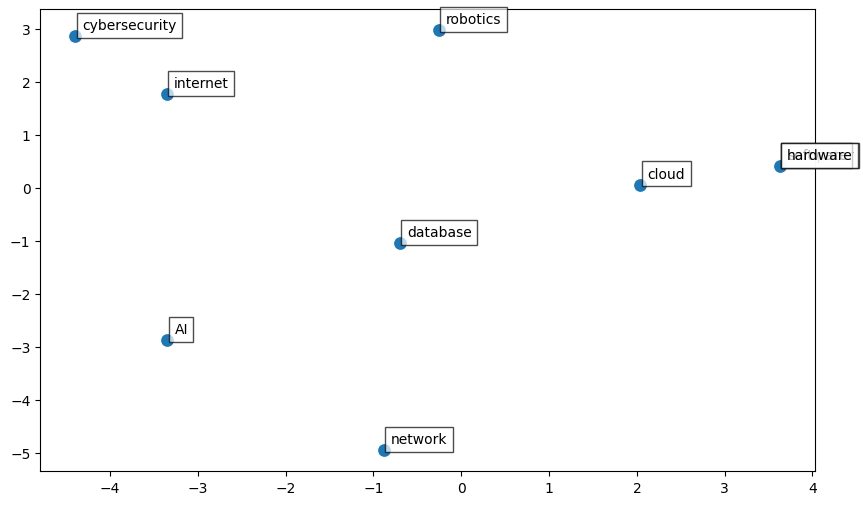

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns, spacy, numpy as np
from sklearn.decomposition import PCA
!python -m spacy download en_core_web_md

nlp = spacy.load("en_core_web_md")
words = ["computer","internet","software","hardware","network","AI","cloud","cybersecurity","database","robotics"]

vecs = np.array([nlp(w).vector for w in words])
p = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(10,6))
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)

for i,w in enumerate(words):
    plt.annotate(w,(p[i,0],p[i,1]),xytext=(5,5),textcoords="offset points",
                 bbox=dict(fc="white",alpha=.7))
plt.show()

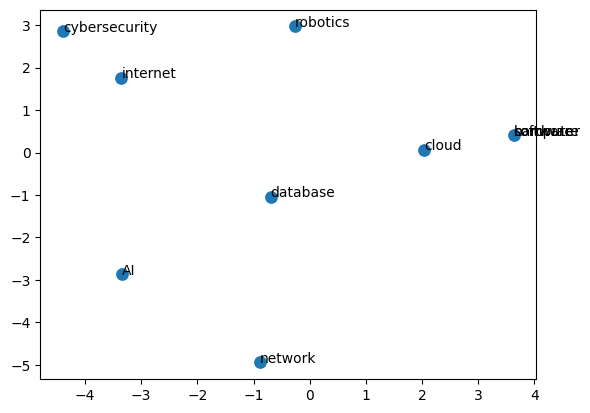

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
nlp=spacy.load('en_core_web_md')
words=["computer","internet","software","hardware","network","AI","cloud","cybersecurity","database","robotics"]
vec=np.array([nlp(w).vector for w in words])
p=PCA(n_components=2).fit_transform(vec)
sns.scatterplot(x=p[:,0],y=p[:,1],s=100)
for i,w in enumerate(words):
  plt.annotate(w,(p[i,0],p[i,1]))
plt.show()

# **program 3**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[('gold', 0.9966838955879211), ('both', 0.9966511726379395), ('large', 0.9965356588363647), ('public', 0.9965243935585022), ('capital', 0.9963962435722351)]


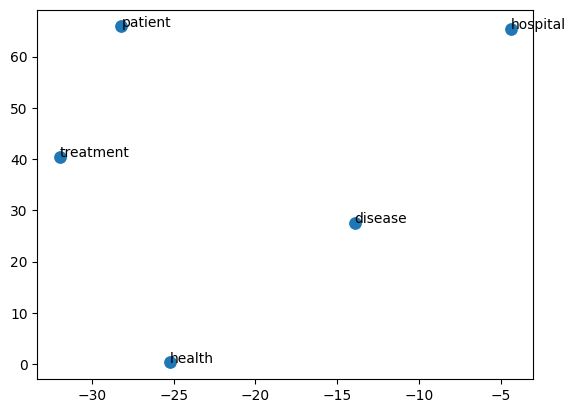

In [ ]:
import nltk, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from nltk.corpus import reuters
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

nltk.download("punkt"); nltk.download("reuters"); nltk.download("punkt_tab")

sents = [[w.lower() for w in s if w.isalpha()] for s in reuters.sents()[:5000]]
model = Word2Vec(sents,min_count=2)

term = "disease"
print(model.wv.most_similar(term, topn=5) if term in model.wv else f"{term} not found")

words = ["health","disease","doctor","patient","treatment","medicine","virus","surgery","nurse","hospital"]
vecs = np.array([model.wv[w] for w in words if w in model.wv])

p = TSNE(n_components=2, perplexity=3).fit_transform(vecs)
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)
for i,w in enumerate([w for w in words if w in model.wv]):
    plt.annotate(w,(p[i,0],p[i,1]))
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


[('both', 0.9956909418106079), ('capital', 0.995578944683075), ('gold', 0.9953891634941101), ('point', 0.995332658290863), ('large', 0.9952084422111511)]


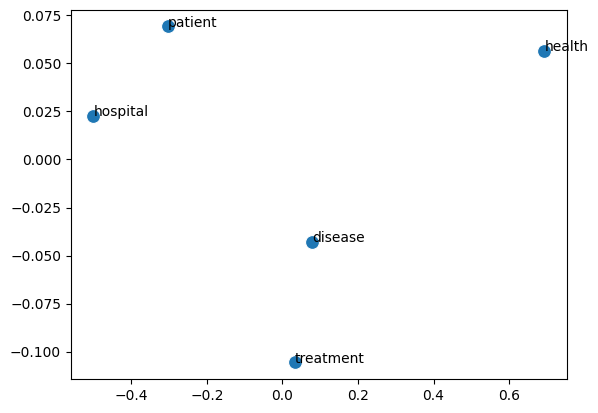

In [5]:
import numpy as np
import nltk
from nltk.corpus import reuters
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('reuters')
sents=[[w.lower() for w in s if w.isalpha()]for s in reuters.sents()[:5000]]
m=Word2Vec(sents,min_count=2)
print(m.wv.most_similar('disease',topn=5))
words=['health','disease','doctor','patient','treatment','medicine','virus','surgery','nurse','hospital']
vecs=np.array([m.wv[w]for w in words if w in m.wv])
p=PCA(n_components=2).fit_transform(vecs)
sns.scatterplot(x=p[:,0],y=p[:,1],s=100)
for i,w in enumerate([w for w in words if w in m.wv]):
  plt.annotate(w,(p[i,0],p[i,1]))
plt.show()


# **Program 4**

In [9]:
import gensim.downloader as api
from transformers import pipeline

wv = api.load("word2vec-google-news-300")
gen = pipeline("text-generation", model="gpt2")

def enrich(text):
    words = []
    for w in text.split():
        words.append(w)
        if w in wv:
            words += [x[0] for x in wv.most_similar(w, topn=2)]
    return " ".join(words)

prompt = "Explain machine learning in healthcare"

print("Original:\n", gen(prompt, max_length=100)[0]["generated_text"])
print("\nEnriched:\n", gen(enrich(prompt), max_length=100)[0]["generated_text"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original:
 Explain machine learning in healthcare.

The idea is that machine learning can be used to predict the future behavior of patients — and so, in medicine, we can use machine learning to help people with chronic diseases. But there are challenges to making machine learning work for people with chronic diseases.

The first is that it's not clear exactly how machine learning works. We know that researchers like to use machine learning to improve the performance of research experiments, but it's unclear if these machine learning techniques work best when they are being applied to the treatment of chronic diseases like diabetes or heart disease.

Researchers have also been using machine learning to help people with a variety of diseases. In 2007, for example, researchers at Stanford University developed a machine learning approach that could predict how people would respond to a specific treatment condition (i.e., patients with a chronic, high-risk condition).

Machine learning is 

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Enriched:
 Explain Describe Remind machine machines wringer_washing learning teaching learn in inthe where healthcare health_care heath_care learning heath_care_learning teaching heath_care_learning learning heath_care_learning learning heath_heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning he

In [1]:
import gensim.downloader as api
from transformers import pipeline
wv=api.load("word2vec-google-news-300")
gen=pipeline('text-generation',model='gpt2')
def enrich(txt):
  wo=[]
  for w in txt.split():
    wo.append(w)
    if w in wv:
      wo+=[x[0]for x in wv.most_similar(w,topn=2)]
  return " ".join(wo)
prompt='Explain Ml in healthcare'
print("OP",gen(prompt,max_length=100)[0]['generated_text'])
print("Enriched:",gen(enrich(prompt),max_length=100)[0]['generated_text'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=Tru

OP Explain Ml in healthcare.

Ml is a term used to describe a state of mind or state of mind that is not immediately obvious, and that is not conducive to an effective treatment. This state is known as "mild" or "moderate" ml; it is defined as having a moderate or increased level of clarity and clarity within the mind and body. The term is also used in the medical community to describe any state of consciousness that is not immediately apparent, and that is not conducive to effective treatment.

A common common misconception is that people who have ml are "moderate" in their mental health. This is not always the case. Many individuals who have ml have developed mental health issues, and some have developed their own illnesses and/or disabilities. Ml is not a condition that is caused by a simple physical condition. For example, if you have asthma or diabetes, you probably have ml, but if you have a high risk of infection, you probably have ml. Therefore, you should not expect to have ml

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Enriched: Explain Describe Remind Ml ####ML megalitre in inthe where healthcare health_care heath_care_health_health_care_health_care_health_care_care_health_care_health_care_health_care_health_care_health_care_health_care_health_care_health_care_private health_care_public health_care_private health_care_private

The following code is the result of my own experimentation on the same topic. The sample program is in the following format:

#include <stdio.h> #include <stdlib.h> #include <stddef.h> #include <stdio.h> #include <string.h> #include <stdlib.h> #include <stdlib.h> #include <string.h> #include <string.h> #include <stdlib.h> #include <string.h> #include <stdlib.h> #include <stdlib.h> #include <stdlib.h> #include <string.h> #include <string.h> #include <string.h> #include <string.h> #include <string.h> #include <string.h> #include <string.h> #include <string.


# **Program 5**

In [1]:
import random, gensim.downloader as api

model = api.load("word2vec-google-news-300")

def gen_para(seed):
    try: w=[x for x,_ in model.most_similar(seed,topn=5)]
    except: w=[seed]
    random.shuffle(w)
    p=f"Once upon a time a {seed} dreamed of adventure. "
    for i in w: p+=f"It found a {i}, starting a strange journey. "
    return p+"It changed everything."

print(gen_para(input("Seed word: ")))

Seed word: dick
Once upon a time a dick dreamed of adventure. It found a ass, starting a strange journey. It found a asshole, starting a strange journey. It found a d_**_k, starting a strange journey. It found a d_*_ck, starting a strange journey. It found a pussy, starting a strange journey. It changed everything.


In [4]:
import gensim.downloader as api
import random
m=api.load('word2vec-google-news-300')
def g(seed):
  try:w=[x for x in wv.most_similar(seed,topn=5)]
  except:w=[seed]
  p=f'Once upon a time there is a {seed},who went on an adventure'
  for i in w: p+=f'{seed} found {i} and became friends'
  return p +'END'
print(g(input('Enter the seed word')))

Enter the seed worddick
Once upon a time there is a dick,who went on an adventuredick found dick and became friendsEND


# **Program 6**

In [5]:
from transformers import pipeline

sent = pipeline("sentiment-analysis")

while True:
    t = input("Enter sentence (exit to quit): ")
    if t.lower() == "exit": break
    r = sent(t)[0]
    print(f"Sentiment: {r['label']} (Confidence: {r['score']:.2f})\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Enter sentence (exit to quit): bang bros
Sentiment: POSITIVE (Confidence: 1.00)

Enter sentence (exit to quit): exit


In [8]:
from transformers import pipelines
m=pipeline('sentiment-analysis')
while True:
  i=input("enter the sentiment")
  if i.lower()=='exit':
    break
  r=m(i)[0]
  print(f"{r['label']},{r['score']}")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

enter the sentimenttits
NEGATIVE,0.8436428308486938
enter the sentimentboobd
NEGATIVE,0.7336501479148865
enter the sentimentboobs
POSITIVE,0.9912943243980408
enter the sentimentpussy
NEGATIVE,0.9785126447677612
enter the sentimentmy pussy cat
NEGATIVE,0.8892260193824768
enter the sentimentexit


# **Program 7**